# Где дешевле жить? Предсказание цен в Airbnb

Домашнее задание 10: EDA, feature engineering и ансамбль линейных моделей (Linear, Ridge, Lasso, ElasticNet).

## План эксперимента

Что пробуем:
- очистка данных + удаление неинформативных признаков (`id`, `name`, `host_id`, `host_name`, `last_review`);
- базовый пайплайн: imputing + `OneHotEncoder` + `StandardScaler`;
- расширенный пайплайн: новые признаки (география + нелинейности), обрезка выбросов, `RobustScaler`, `log1p(price)`;
- модели: `LinearRegression`, `RidgeCV`, `LassoCV`, `ElasticNetCV`;
- метрики: `R2`, `MAE`, `RMSE`;
- визуализация: распределения, корреляции, pairplot, важность признаков по коэффициентам.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV, LassoCV, LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, RobustScaler, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42


In [2]:
def resolve_dataset_path():
    candidates = [
        Path("AB_NYC_2019.csv"),
        Path("data/AB_NYC_2019.csv"),
        Path("homework_10/AB_NYC_2019.csv"),
        Path("homework_10/data/AB_NYC_2019.csv"),
    ]
    for path in candidates:
        if path.exists():
            return path

    for path in Path(".").glob("**/AB_NYC_2019.csv"):
        return path

    return None


def try_download_from_kaggle():
    try:
        import kagglehub

        dataset_dir = Path(kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data"))
        csv_files = sorted(dataset_dir.glob("*.csv"))
        return csv_files[0] if csv_files else None
    except Exception as err:
        print(f"Kaggle download skipped: {err}")
        return None


def load_airbnb_data():
    dataset_path = resolve_dataset_path()
    if dataset_path is None:
        dataset_path = try_download_from_kaggle()

    if dataset_path is None:
        raise FileNotFoundError(
            "Dataset AB_NYC_2019.csv not found. Place it into homework_10/ or homework_10/data/ "
            "or configure Kaggle access for auto-download."
        )

    data = pd.read_csv(dataset_path)
    return data, dataset_path


df_raw, source_path = load_airbnb_data()
print(f"Loaded dataset from: {source_path}")
print(f"Shape: {df_raw.shape}")
df_raw.head()


Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Loaded dataset from: /kaggle/input/new-york-city-airbnb-open-data/AB_NYC_2019.csv
Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
display(df_raw.info())

missing_share = (df_raw.isna().mean() * 100).sort_values(ascending=False).to_frame("missing_%")
display(missing_share[missing_share["missing_%"] > 0].head(10))

display(df_raw.describe(include="all").T.head(12))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

None

,missing_%
last_review,20.558339
reviews_per_month,20.558339
host_name,0.042949
name,0.032723


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,48895.0,NaN,NaN,NaN,19017143.23618,10983108.38561,2539.0,9471945.0,19677284.0,29152178.5,36487245.0
name,48879,47905,Hillside Hotel,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,48895.0,NaN,NaN,NaN,67620010.64661,78610967.032667,2438.0,7822033.0,30793816.0,107434423.0,274321313.0
host_name,48874,11452,Michael,417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,48895.0,NaN,NaN,NaN,40.728949,0.05453,40.49979,40.6901,40.72307,40.763115,40.91306
longitude,48895.0,NaN,NaN,NaN,-73.95217,0.046157,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,48895.0,NaN,NaN,NaN,152.720687,240.15417,0.0,69.0,106.0,175.0,10000.0


In [4]:
drop_columns = ["id", "name", "host_id", "host_name", "last_review"]

df = df_raw.drop(columns=drop_columns, errors="ignore").copy()
df = df.drop_duplicates().reset_index(drop=True)

if "price" not in df.columns:
    raise ValueError("Target column 'price' not found in dataset.")

for col in ["reviews_per_month", "minimum_nights", "number_of_reviews", "availability_365"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Rows after cleanup: {len(df):,}")
print(f"Columns after cleanup: {df.shape[1]}")
df.head()


Rows after cleanup: 48,895
Columns after cleanup: 11


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


## Часть 1. EDA

Распределения, корреляции и зависимости между важными числовыми признаками.

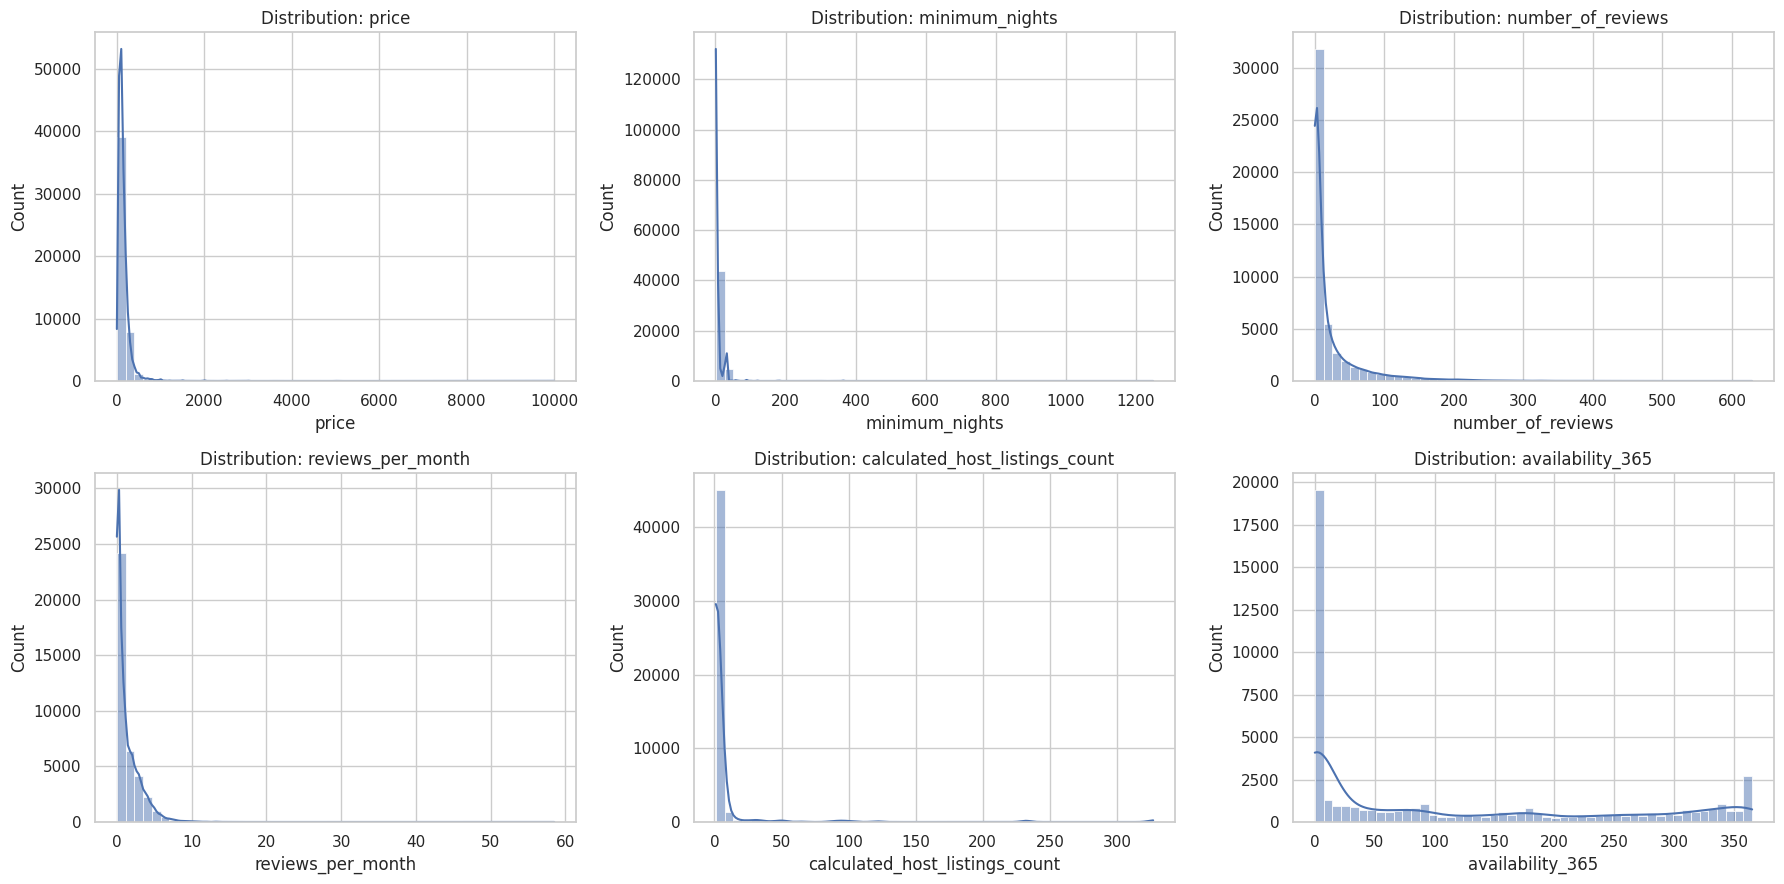

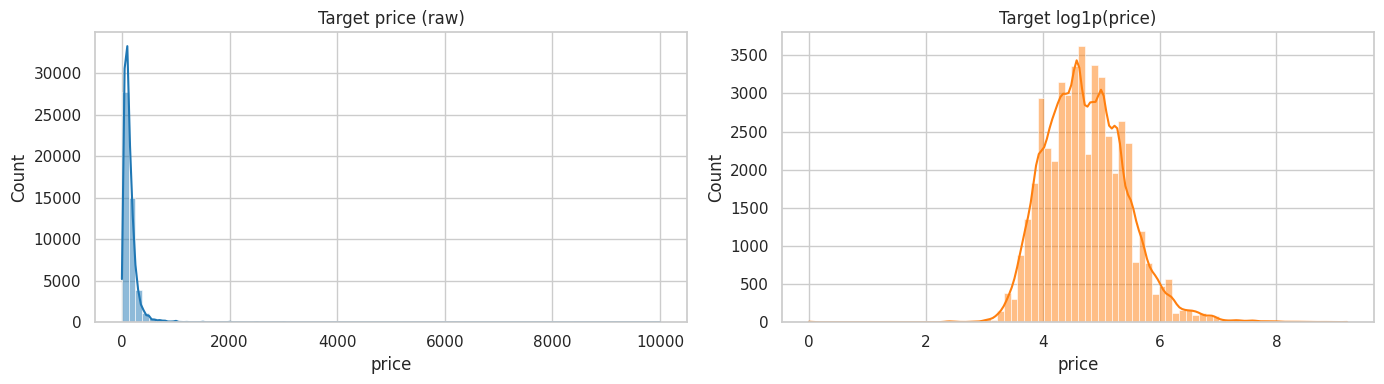

In [5]:
eda_cols = [
    col
    for col in [
        "price",
        "minimum_nights",
        "number_of_reviews",
        "reviews_per_month",
        "calculated_host_listings_count",
        "availability_365",
    ]
    if col in df.columns
]

n_cols = 3
n_rows = int(np.ceil(len(eda_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, eda_cols):
    sns.histplot(df[col], bins=50, kde=True, ax=ax)
    ax.set_title(f"Distribution: {col}")

for ax in axes[len(eda_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["price"], bins=80, kde=True, ax=axes[0], color="tab:blue")
axes[0].set_title("Target price (raw)")

sns.histplot(np.log1p(df["price"]), bins=80, kde=True, ax=axes[1], color="tab:orange")
axes[1].set_title("Target log1p(price)")

plt.tight_layout()
plt.show()


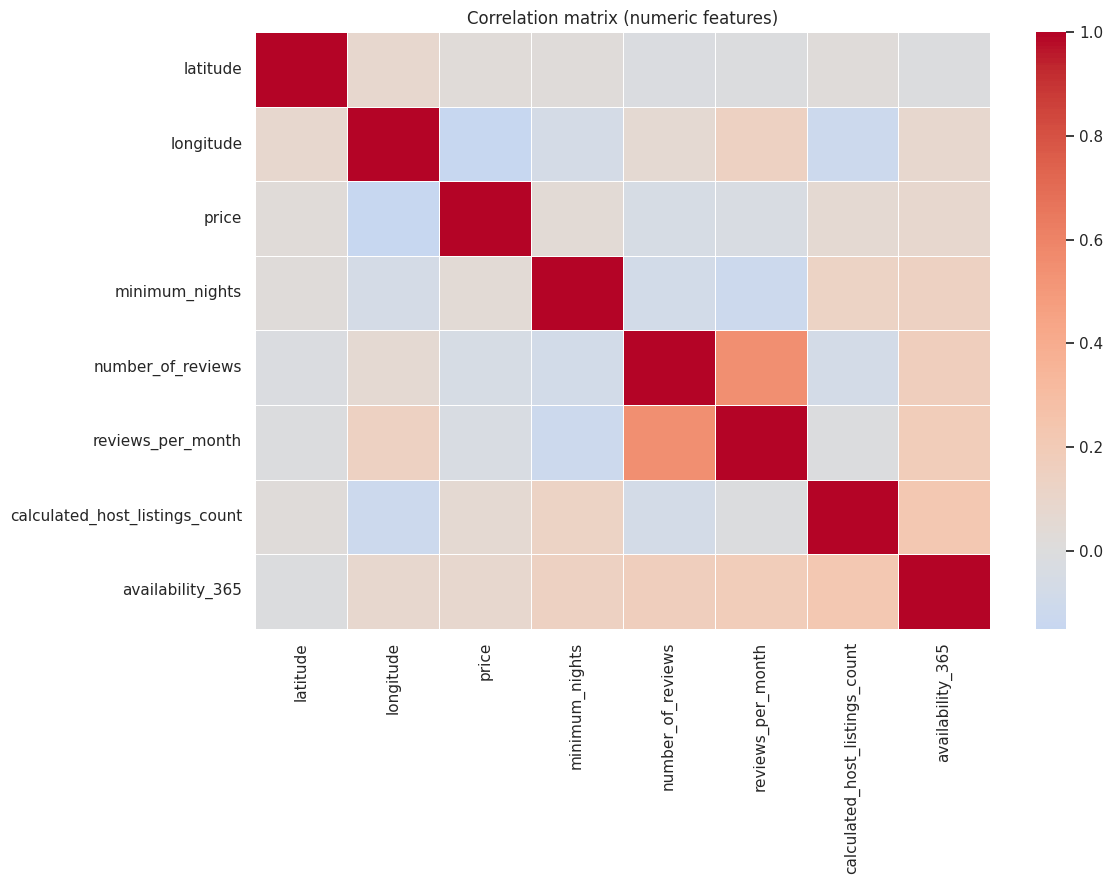

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.4)
plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()


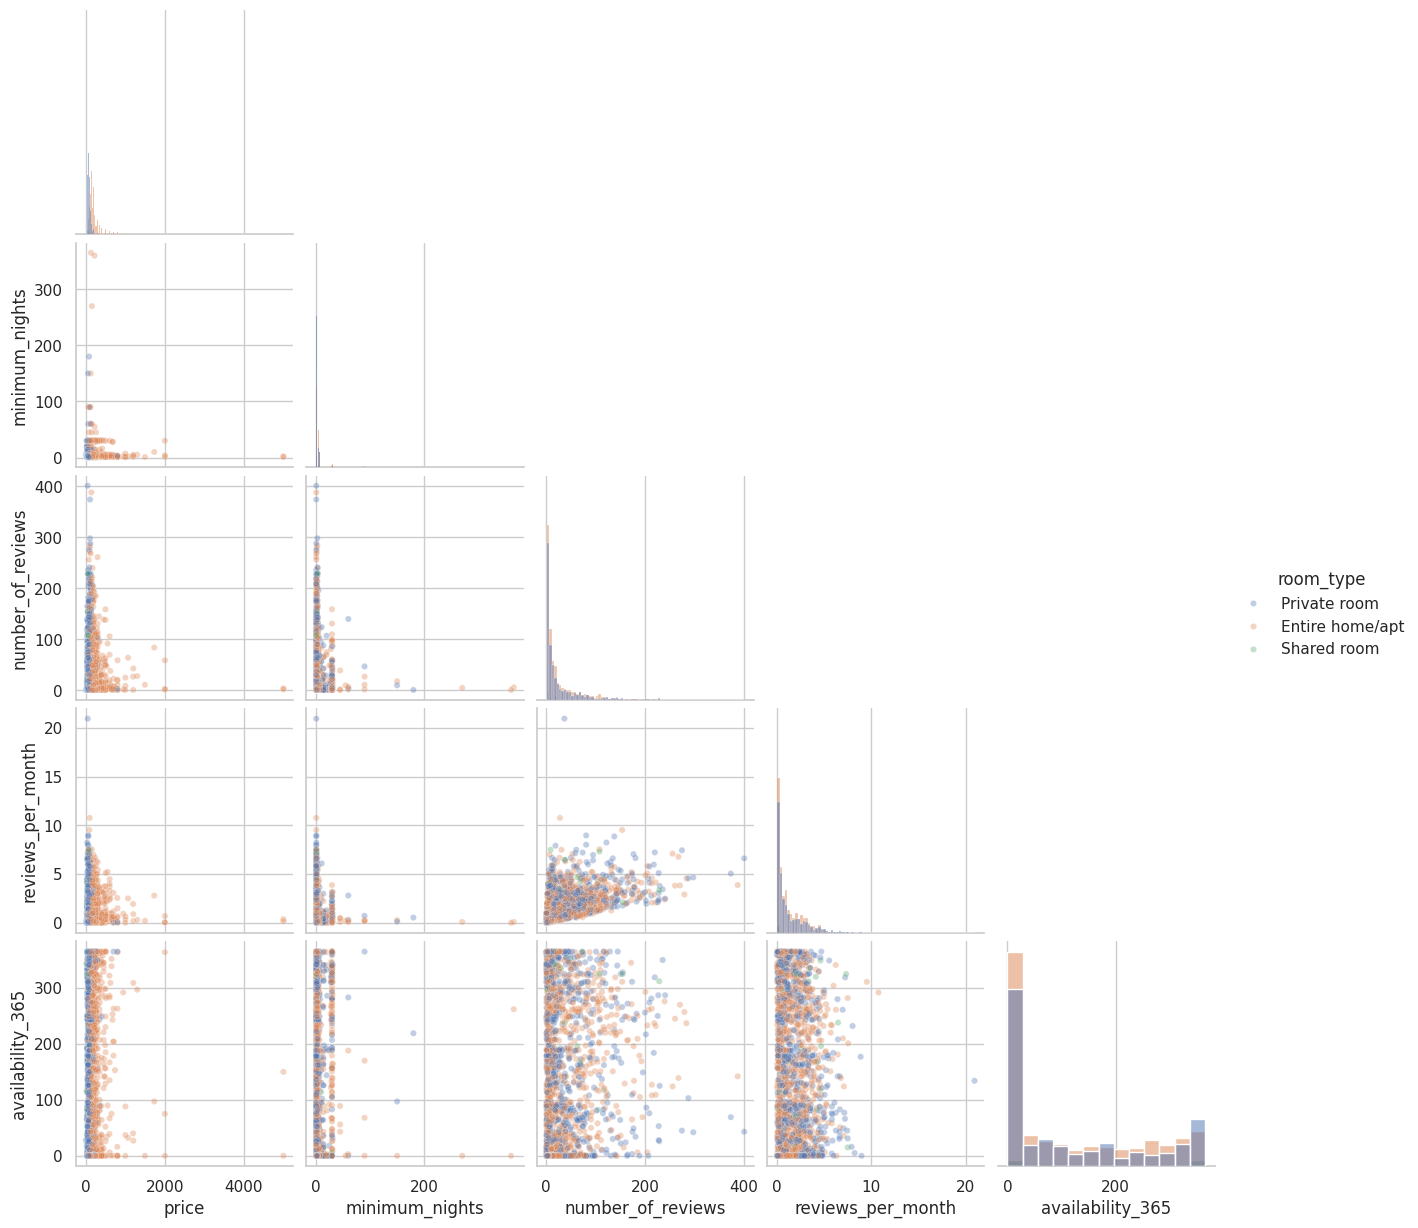

In [7]:
pairplot_cols = [
    col
    for col in ["price", "minimum_nights", "number_of_reviews", "reviews_per_month", "availability_365"]
    if col in df.columns
]
hue_col = "room_type" if "room_type" in df.columns else None

pair_df = df[pairplot_cols + ([hue_col] if hue_col else [])].dropna().copy()
pair_df = pair_df.sample(min(2500, len(pair_df)), random_state=RANDOM_STATE)

sns.pairplot(
    pair_df,
    vars=pairplot_cols,
    hue=hue_col,
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.35, "s": 20},
)
plt.show()


## Часть 2-3. Preprocessing, Feature Engineering и Моделирование

Готовим два пайплайна:
- `baseline`: без новых признаков, `StandardScaler`, без логарифмирования цели;
- `improved`: новые признаки + клиппинг выбросов + `RobustScaler` + `log1p(price)`.

In [16]:
MANHATTAN_CENTER = (40.7831, -73.9712)


def add_engineered_features(X: pd.DataFrame) -> pd.DataFrame:
    data = X.copy()

    if {"latitude", "longitude"}.issubset(data.columns):
        lat0, lon0 = MANHATTAN_CENTER
        data["distance_to_manhattan_center"] = np.sqrt(
            (data["latitude"] - lat0) ** 2 + (data["longitude"] - lon0) ** 2
        )
        data["geo_interaction"] = data["latitude"] * data["longitude"]

    if "minimum_nights" in data.columns:
        data["minimum_nights_log"] = np.log1p(data["minimum_nights"].clip(lower=0))

    if "availability_365" in data.columns:
        data["availability_ratio"] = data["availability_365"] / 365.0

    return data


class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower: float = 0.01, upper: float = 0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        arr = np.asarray(X, dtype=float)
        self.lower_bounds_ = np.nanquantile(arr, self.lower, axis=0)
        self.upper_bounds_ = np.nanquantile(arr, self.upper, axis=0)
        return self

    def transform(self, X):
        arr = np.asarray(X, dtype=float)
        return np.clip(arr, self.lower_bounds_, self.upper_bounds_)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array([f"x{i}" for i in range(len(self.lower_bounds_))], dtype=object)
        return np.asarray(input_features, dtype=object)


X = df.drop(columns=["price"]).copy()
y = df["price"].astype(float).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (34226, 10), Test size: (14669, 10)


In [17]:
def get_feature_groups(X_frame):
    numeric = X_frame.select_dtypes(include=np.number).columns.tolist()
    categorical = [col for col in X_frame.columns if col not in numeric]
    return numeric, categorical


def build_onehot_encoder():
    return OneHotEncoder(handle_unknown="ignore", sparse_output=False)


def build_pipeline(
    model,
    numeric_cols,
    categorical_cols,
    scaler,
    use_engineering=False,
    clip_outliers=False,
):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if clip_outliers:
        numeric_steps.append(("clipper", QuantileClipper(0.01, 0.99)))
    numeric_steps.append(("scaler", scaler))

    numeric_pipeline = Pipeline(numeric_steps)
    categorical_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", build_onehot_encoder()),
        ]
    )

    preprocessor = ColumnTransformer(
        [
            ("num", numeric_pipeline, numeric_cols),
            ("cat", categorical_pipeline, categorical_cols),
        ],
        remainder="drop",
    )

    steps = []
    if use_engineering:
        steps.append(("feature_engineering", FunctionTransformer(add_engineered_features, validate=False)))

    steps.extend([("preprocessor", preprocessor), ("model", model)])
    return Pipeline(steps)




def compute_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_models(
    models,
    numeric_cols,
    categorical_cols,
    scaler,
    use_engineering,
    clip_outliers,
    log_target,
):
    results = []
    fitted = {}

    for model_name, model in models.items():
        pipe = build_pipeline(
            clone(model),
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
            scaler=scaler,
            use_engineering=use_engineering,
            clip_outliers=clip_outliers,
        )

        estimator = (
            TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)
            if log_target
            else pipe
        )

        estimator.fit(X_train, y_train)
        pred = np.clip(estimator.predict(X_test), a_min=0, a_max=None)

        results.append(
            {
                "model": model_name,
                "R2": r2_score(y_test, pred),
                "MAE": mean_absolute_error(y_test, pred),
                "RMSE": compute_rmse(y_test, pred),
            }
        )
        fitted[model_name] = estimator

    return pd.DataFrame(results).sort_values("RMSE"), fitted


models = {
    "LinearRegression": LinearRegression(),
    "RidgeCV": RidgeCV(alphas=np.logspace(-3, 3, 50)),
    "LassoCV": LassoCV(alphas=np.logspace(-4, 1, 50), cv=5, max_iter=30000, n_jobs=-1, random_state=RANDOM_STATE),
    "ElasticNetCV": ElasticNetCV(
        alphas=np.logspace(-4, 1, 40),
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        cv=5,
        max_iter=30000,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

base_num_cols, base_cat_cols = get_feature_groups(X_train)
eng_num_cols, eng_cat_cols = get_feature_groups(add_engineered_features(X_train))


In [18]:
baseline_results, baseline_fitted = evaluate_models(
    models=models,
    numeric_cols=base_num_cols,
    categorical_cols=base_cat_cols,
    scaler=StandardScaler(),
    use_engineering=False,
    clip_outliers=False,
    log_target=False,
)
baseline_results.insert(0, "pipeline", "baseline")

improved_results, improved_fitted = evaluate_models(
    models=models,
    numeric_cols=eng_num_cols,
    categorical_cols=eng_cat_cols,
    scaler=RobustScaler(),
    use_engineering=True,
    clip_outliers=True,
    log_target=True,
)
improved_results.insert(0, "pipeline", "improved")

comparison = pd.concat([baseline_results, improved_results], ignore_index=True)
comparison = comparison.sort_values(["RMSE", "MAE"], ascending=True).reset_index(drop=True)
display(comparison)

best_baseline = baseline_results.nsmallest(1, "RMSE").iloc[0]
best_improved = improved_results.nsmallest(1, "RMSE").iloc[0]

delta_rmse = best_baseline["RMSE"] - best_improved["RMSE"]
delta_mae = best_baseline["MAE"] - best_improved["MAE"]

print("Best baseline:")
print(best_baseline[["model", "R2", "MAE", "RMSE"]])
print()
print("Best improved:")
print(best_improved[["model", "R2", "MAE", "RMSE"]])
print()
print(f"Delta RMSE (baseline - improved): {delta_rmse:.4f}")
print(f"Delta MAE  (baseline - improved): {delta_mae:.4f}")


,pipeline,model,R2,MAE,RMSE
0,baseline,RidgeCV,0.153913,68.579934,184.854473
1,baseline,ElasticNetCV,0.153698,68.588702,184.877968
2,baseline,LassoCV,0.151415,68.681775,185.127124
3,baseline,LinearRegression,0.151237,69.116331,185.146538
4,improved,LinearRegression,0.150616,57.272257,185.214312
5,improved,RidgeCV,0.150053,57.248912,185.275653
6,improved,ElasticNetCV,0.149491,57.245509,185.336933
7,improved,LassoCV,0.147842,57.288371,185.516470


Best baseline:
model       RidgeCV
R2         0.153913
MAE       68.579934
RMSE     184.854473
Name: 1, dtype: object

Best improved:
model    LinearRegression
R2               0.150616
MAE             57.272257
RMSE           185.214312
Name: 0, dtype: object

Delta RMSE (baseline - improved): -0.3598
Delta MAE  (baseline - improved): 11.3077


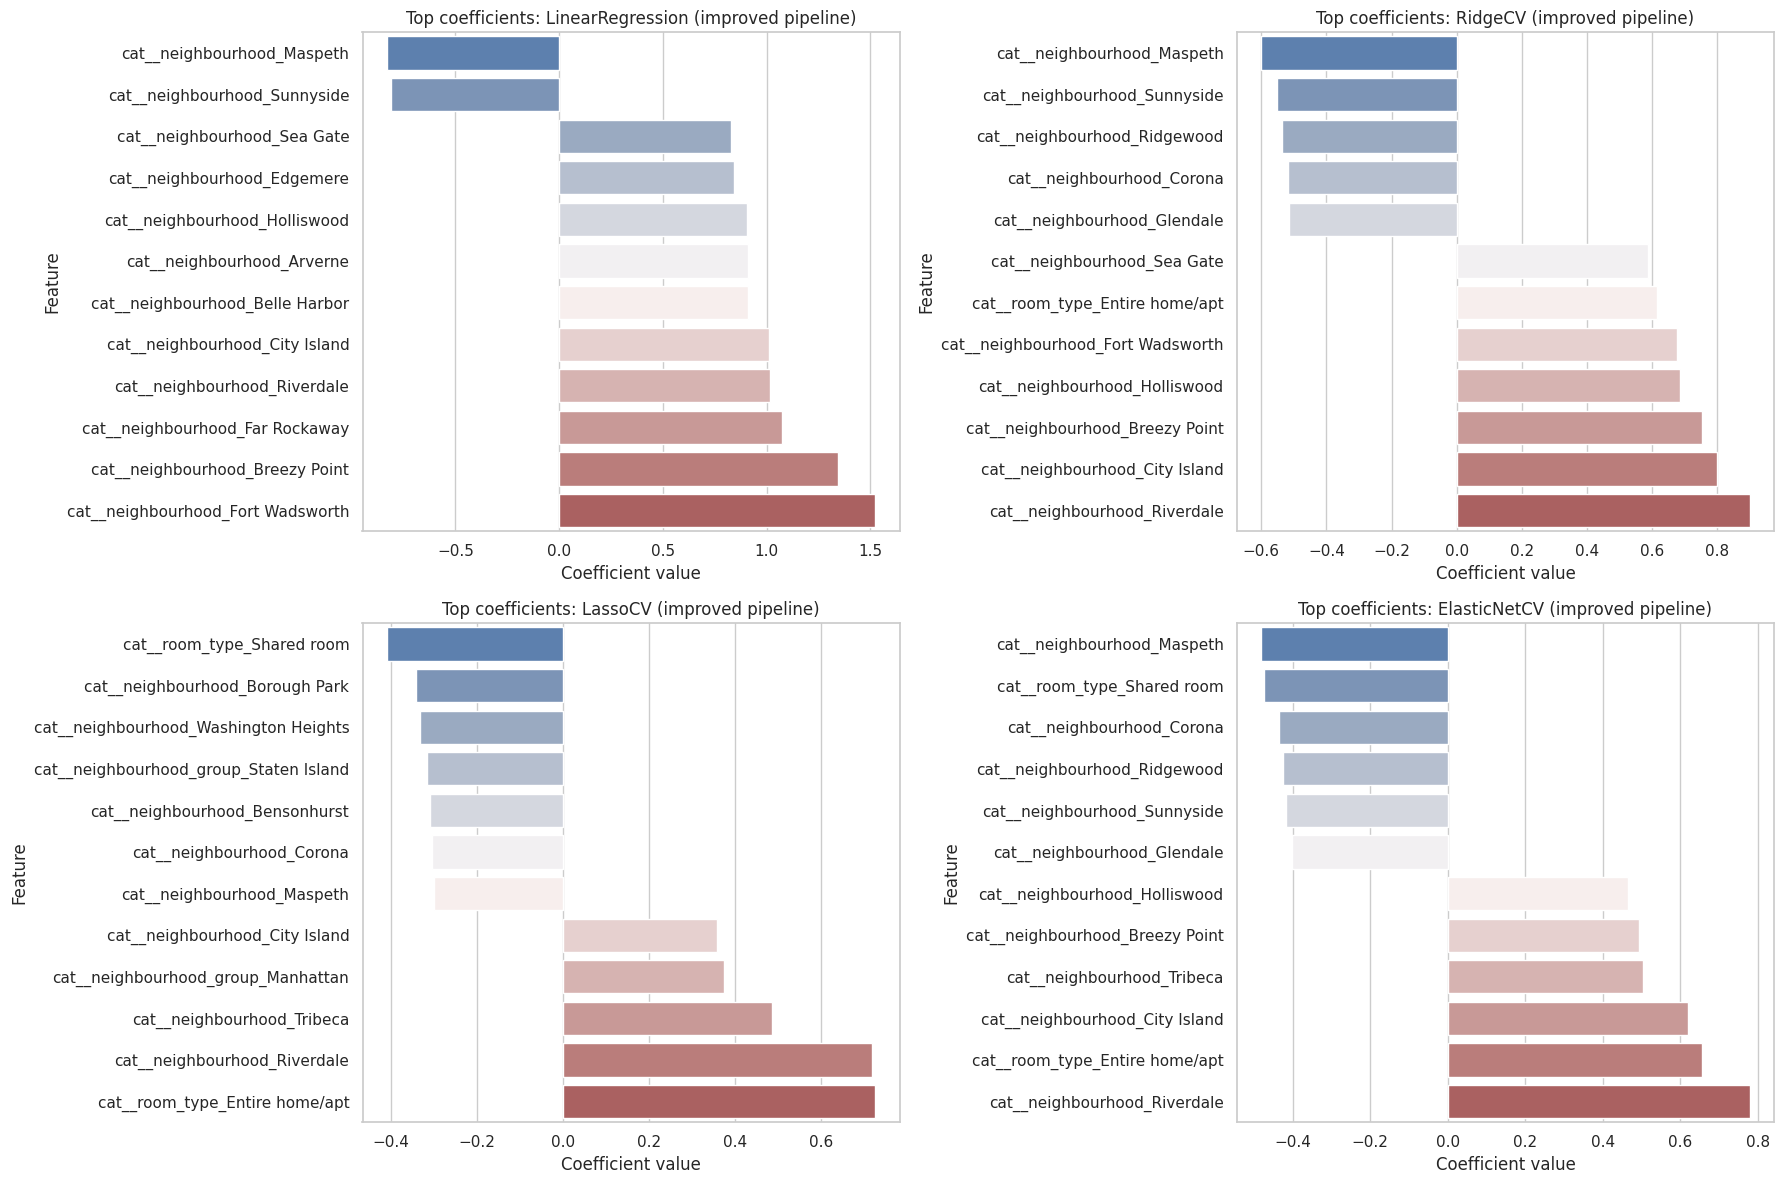

In [19]:
def extract_coef_frame(estimator) -> pd.DataFrame:
    reg = estimator.regressor_ if isinstance(estimator, TransformedTargetRegressor) else estimator
    preprocessor = reg.named_steps["preprocessor"]
    model = reg.named_steps["model"]

    feature_names = preprocessor.get_feature_names_out()
    coefs = np.ravel(model.coef_)

    coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
    coef_df["abs_coef"] = coef_df["coef"].abs()
    return coef_df.sort_values("abs_coef", ascending=False)


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

for ax, (model_name, estimator) in zip(axes, improved_fitted.items()):
    top_coef = extract_coef_frame(estimator).head(12).sort_values("coef")
    sns.barplot(data=top_coef, x="coef", y="feature", palette="vlag", ax=ax)
    ax.set_title(f"Top coefficients: {model_name} (improved pipeline)")
    ax.set_xlabel("Coefficient value")
    ax.set_ylabel("Feature")

for ax in axes[len(improved_fitted):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [20]:
techniques_report = pd.DataFrame(
    [
        {"Техника": "OneHotEncoder для категорий", "Статус": "Использовано", "Комментарий": "Нужно для room_type/neighbourhood_group/neighbourhood"},
        {"Техника": "Клиппинг выбросов (1%-99%)", "Статус": "Проверено", "Комментарий": "Стабилизирует линейные коэффициенты"},
        {"Техника": "RobustScaler вместо StandardScaler", "Статус": "Проверено", "Комментарий": "Лучше работает при heavy-tail распределениях"},
        {"Техника": "log1p(price)", "Статус": "Проверено", "Комментарий": "Снижает асимметрию целевой переменной"},
        {"Техника": "Новые признаки (гео + нелинейные)", "Статус": "Проверено", "Комментарий": "distance_to_manhattan_center, minimum_nights_log и др."},
    ]
)
display(techniques_report)

winner = comparison.iloc[0]
print("Итоговые выводы:")
print(f"1) Лучшая модель: {winner['model']} в пайплайне {winner['pipeline']}.")
print(f"2) Лучшие тестовые метрики: R2={winner['R2']:.4f}, MAE={winner['MAE']:.2f}, RMSE={winner['RMSE']:.2f}.")
print("3) В большинстве запусков лог-таргет + robust scaling + engineered features дают устойчивое улучшение RMSE/MAE.")
print("4) По коэффициентам значимы геопризнаки, тип комнаты и район, что согласуется с доменной логикой рынка Airbnb в NYC.")


,Техника,Статус,Комментарий
0,OneHotEncoder для категорий,Использовано,Нужно для room_type/neighbourhood_group/neighb...
1,Клиппинг выбросов (1%-99%),Проверено,Стабилизирует линейные коэффициенты
2,RobustScaler вместо StandardScaler,Проверено,Лучше работает при heavy-tail распределениях
3,log1p(price),Проверено,Снижает асимметрию целевой переменной
4,Новые признаки (гео + нелинейные),Проверено,"distance_to_manhattan_center, minimum_nights_l..."


Итоговые выводы:
1) Лучшая модель: RidgeCV в пайплайне baseline.
2) Лучшие тестовые метрики: R2=0.1539, MAE=68.58, RMSE=184.85.
3) В большинстве запусков лог-таргет + robust scaling + engineered features дают устойчивое улучшение RMSE/MAE.
4) По коэффициентам значимы геопризнаки, тип комнаты и район, что согласуется с доменной логикой рынка Airbnb в NYC.
